# Funciones:

In [16]:
import pandas as pd
import numpy as np
import neurokit2 as nk
import ast

# extraction function for a single row
def extract_nk2_features(row, sr=500):
    # Convert lists back to numpy arrays
    ecg_raw = np.array(row['ECG'])
    eda_raw = np.array(row['EDA'])
    rsp_raw = np.array(row['RR']) # Respiration
    
    features = {}
    
    # ECG
    try:
        # nk.ecg_process cleans the wave and finds the R-peaks (heartbeats)
        ecg_signals, _ = nk.ecg_process(ecg_raw, sampling_rate=sr)
        # nk.ecg_intervalrelated calculates HRV, Mean HR, etc. for the whole window
        ecg_feat = nk.ecg_intervalrelated(ecg_signals)
        for col in ecg_feat.columns:
            features[col] = ecg_feat[col].iloc[0]
    except Exception:
        pass # If the window is too noisy, leave features empty (will become NaN)

    # Process EDA
    try:
        eda_signals, _ = nk.eda_process(eda_raw, sampling_rate=sr)
        eda_feat = nk.eda_intervalrelated(eda_signals)
        for col in eda_feat.columns:
            features[col] = eda_feat[col].iloc[0]
    except Exception:
        pass

    # Process Respiration (RR)
    try:
        rsp_signals, _ = nk.rsp_process(rsp_raw, sampling_rate=sr)
        rsp_feat = nk.rsp_intervalrelated(rsp_signals)
        for col in rsp_feat.columns:
            features[col] = rsp_feat[col].iloc[0]
    except Exception:
        pass
        
    # Return as a Pandas Series so it easily expands into columns
    return pd.Series(features)


#The [[v]] values are obviously wrong, so we need to extract them
def extract_scalar(val):
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return np.nan

    try:
        return float(val[0][0])
    except (TypeError, IndexError, ValueError):
        return np.nan
    


def preprocess(df, threshold=30):
    '''
    Preprocesamiento centrado en la limpieza del dataframe de features.
    1. Elimina infs.
    2. Elimina columnas con NaNs superiores al porcentaje igual a "threshold"
    3. Elimina filas con algún NaN.
    4. Extrae los valores con formato [[v]].
    '''
    df = df.replace([np.inf, -np.inf], np.nan)

    missing_percentages = df.isna().sum() / len(df) * 100

    cols_to_drop = missing_percentages[missing_percentages > threshold].index
    df = df.drop(columns=cols_to_drop)
    df = df.dropna()

    
    feature_cols = [col for col in df.select_dtypes(include="object").columns if col not in ['subject', 'activity', 'window_id']]
    for col in feature_cols:
        df[col] = df[col].apply(extract_scalar)
    
    return df

def normalize(df, by=['Baseline', 'Relax'], clean = True):
    '''
    Normalización por sujeto usando Z-score, en base a la actividad especificada con param "by".
    '''

    feature_cols = [col for col in df.columns if col not in ['subject', 'activity', 'window_id']]

    # Aislar los datos de baseline para calcular la referencia
    df_baseline = df[df['activity'].isin(by)]


    # Calcular la media y std de cada característica durante el baseline, agrupado por sujeto
    baseline_means = df_baseline.groupby('subject')[feature_cols].mean().reset_index()
    baseline_stds = df_baseline.groupby('subject')[feature_cols].std().reset_index()

    # Fusionar (merge) estas medias con el dataframe original
    # con sufijos a las columnas para diferenciarlas
    df_norm = pd.merge(df, baseline_means, on='subject', suffixes=('', '_mean'))
    df_norm = pd.merge(df_norm, baseline_stds, on='subject', suffixes=('', '_std'))

    # Aplicar la normalización z score
    # Restamos el valor base al valor de la ventana actual para aislar el cambio
    for col in feature_cols:
        df_norm[col] = (df_norm[col] - df_norm[f"{col}_mean"]) / (df_norm[f"{col}_std"] + 1e-8)

    # Eliminar las columnas _mean, _std
    columnas_auxiliares = [f"{col}_mean" for col in feature_cols] + [f"{col}_std" for col in feature_cols]
    df_norm.drop(columns=columnas_auxiliares, inplace=True)

    if clean:
        df_norm = preprocess(df_norm)

    return df_norm


def feature_extraction_and_normalization(df, threshold=30, by=['Baseline', 'Relax'], clean = True):
    '''
    Aplicar el proceso global de extracción de características + limpieza + normalización + limpieza
    '''
    features_df = df.apply(extract_nk2_features, axis=1)
    df_features = pd.concat(
    [df[['subject', 'activity', 'window_id']], features_df], 
    axis=1
    )

    df_features = preprocess(df_features, threshold=threshold)
    df_features = normalize(df_features, by = by, clean = clean)

    return df_features
    

Ahora los datos fueron capturados con una frecuencia de 500 hz, lo cual equivale a 500 puntos o filas por segundo.

In [ ]:
import os
import pandas as pd
import numpy as np

SAMPLING_RATE = 500
WINDOW_SIZE_SEC = 30
SAMPLES_PER_WINDOW = SAMPLING_RATE * WINDOW_SIZE_SEC  # 2500
PATH = '../Dataset_StressID/StressIDDataset/StressID/StressID Dataset/Physiological'

# 1. Create an empty list to hold all our row dictionaries
all_session_rows = []

for subject in os.listdir(PATH):
    subject_path = os.path.join(PATH, subject)
        
    for file in os.listdir(subject_path):

        # Load the data
        file_path = os.path.join(subject_path, file)
        df_physio = pd.read_csv(file_path)
        
        # Extract activity from filename 
        activity = os.path.basename(file_path).split('.')[0].split('_')[1]

        # Extract and shape the signals
        raw_signals = df_physio[['ECG', 'EDA', 'RR']].values
        num_full_windows = len(raw_signals) // SAMPLES_PER_WINDOW
        truncated_signals = raw_signals[:num_full_windows * SAMPLES_PER_WINDOW]
        physio_windows = truncated_signals.reshape(num_full_windows, SAMPLES_PER_WINDOW, 3)

        # 2. Loop through the generated windows and add them to our master list
        for w in range(num_full_windows):
            all_session_rows.append({
                'subject': subject,
                'activity': activity,
                'window_id': w,
                # .tolist() converts the NumPy array into a standard Python list 
                # so it fits perfectly inside the Pandas cell
                'ECG': physio_windows[w, :, 0].tolist(), 
                'EDA': physio_windows[w, :, 1].tolist(),
                'RR':  physio_windows[w, :, 2].tolist()
            })

# 3. Create the final DataFrame in one massive, lightning-fast operation
df_final_physio = pd.DataFrame(all_session_rows)

df_final_physio

,subject,activity,window_id,ECG,EDA,RR
0,2ea4,Baseline,0,"[33140, 33240, 33564, 33800, 33836, 33726, 335...","[39014, 38980, 38951, 38935, 38919, 38935, 389...","[40531, 40460, 40613, 40740, 40596, 40792, 407..."
1,2ea4,Baseline,1,"[33706, 33796, 34028, 34244, 34528, 34852, 347...","[52512, 52516, 52445, 52463, 52453, 52460, 524...","[25223, 25356, 25374, 25081, 25172, 24877, 250..."
2,2ea4,Breathing,0,"[32412, 32664, 32964, 33132, 33148, 33097, 328...","[34999, 34973, 34932, 34919, 34934, 34936, 349...","[31878, 31924, 31852, 31940, 31948, 31910, 319..."
3,2ea4,Breathing,1,"[31968, 32192, 32423, 32748, 33036, 33024, 329...","[44337, 44317, 44294, 44263, 44232, 44221, 442...","[26448, 26248, 26388, 26388, 26375, 26377, 264..."
4,2ea4,Breathing,2,"[30368, 30480, 30720, 31104, 31472, 31564, 314...","[41807, 41804, 41791, 41745, 41747, 41757, 417...","[35175, 35159, 35151, 35135, 35068, 35058, 350..."
...,...,...,...,...,...,...
2245,y9z6,Video1,3,"[32628, 32640, 32636, 32676, 32704, 32748, 327...","[9453, 9380, 9387, 9443, 9550, 9517, 9540, 954...","[29066, 29087, 29236, 29281, 29356, 29465, 295..."
2246,y9z6,Video1,4,"[33218, 33183, 33172, 33216, 33184, 33116, 330...","[6829, 6849, 6972, 6940, 6913, 6860, 6959, 684...","[43381, 43381, 43335, 43212, 43372, 43461, 435..."
2247,y9z6,Video2,0,"[32992, 32916, 32869, 32840, 32880, 32944, 330...","[14069, 14043, 14016, 13937, 13980, 14023, 140...","[27607, 27496, 27829, 27793, 27712, 27941, 279..."
2248,y9z6,Video2,1,"[33238, 33300, 33304, 33364, 33372, 33333, 333...","[10321, 10292, 10375, 10405, 10445, 10323, 103...","[22356, 22384, 22267, 22346, 22412, 22364, 223..."


In [ ]:
extracted_features_df = df_final_physio.apply(extract_nk2_features, axis=1)

# Combine the identifiers with the new features
# We drop the raw array columns here because we don't need them anymore!
df_features = pd.concat(
    [df_final_physio[['subject', 'activity', 'window_id']], extracted_features_df], 
    axis=1
)

print(f"Extracted {len(df_features.columns) - 3} new physiological features.")
df_features

Extracting features (this may take a while)...


/home/ethe/miniconda3/envs/rl_env/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/ethe/miniconda3/envs/rl_env/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/ethe/miniconda3/envs/rl_env/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller t

Extracted 124 new physiological features.


,subject,activity,window_id,ECG_Rate_Mean,EDA_Autocorrelation,EDA_Sympathetic,EDA_SympatheticN,EDA_Tonic_SD,HRV_AI,HRV_ApEn,...,RRV_VLF,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
0,2ea4,Baseline,0,63.911428,NaN,NaN,NaN,5040.640929,[[51.82634743154224]],[[0.37321546141287953]],...,NaN,0.782111,0.703700,0.899744,4204.267968,21.025809,0.692110,0.507944,5250.981592,6.0
1,2ea4,Baseline,1,62.374688,NaN,NaN,NaN,2643.282806,[[48.535258768221595]],[[0.18237754735420308]],...,NaN,1.014750,0.533444,0.525691,3851.974987,20.550898,0.668411,0.369818,2418.912870,4.0
2,2ea4,Breathing,0,59.237845,NaN,NaN,NaN,1270.940363,[[53.29653332643767]],[[0.16368705782089732]],...,NaN,1.784667,1.370250,0.767790,2988.182481,10.990455,NaN,NaN,4356.943513,4.0
3,2ea4,Breathing,1,59.916269,NaN,NaN,NaN,1541.987407,[[46.523535582794366]],[[0.3316789812835763]],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2205.520518,3.0
4,2ea4,Breathing,2,59.629026,NaN,NaN,NaN,1235.239997,[[45.05730049477715]],[[0.2268983942058025]],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2720.527923,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,y9z6,Video1,3,59.152329,NaN,NaN,NaN,774.816374,[[53.291440161756654]],[[0.11629237880825283]],...,NaN,0.789714,0.696625,0.882123,10904.344552,19.884393,0.605556,0.455068,15.609545,26.0
2246,y9z6,Video1,4,58.525695,NaN,NaN,NaN,874.925919,[[49.619059244818246]],[[0.2751001983228436]],...,NaN,0.721125,0.694111,0.962539,10376.135531,20.937372,0.624524,0.486218,1410.614702,1.0
2247,y9z6,Video2,0,59.842817,NaN,NaN,NaN,1298.294392,[[53.842881182810764]],[[0.23227273136360083]],...,NaN,0.927833,0.855571,0.922118,9891.813123,16.533629,0.697378,0.495879,7.041356,2.0
2248,y9z6,Video2,1,57.310237,NaN,NaN,NaN,1069.315923,[[50.14558391635426]],[[0.06494814321121911]],...,NaN,0.826333,0.778857,0.942546,8561.454122,18.949237,0.642947,0.488253,12.794270,36.0


In [9]:
df_features.to_csv('./physiological_features_raw.csv', index=False)

In [77]:
import pandas as pd
df_features = pd.read_csv('./physiological_features_raw.csv')
df_features

,subject,activity,window_id,ECG_Rate_Mean,EDA_Autocorrelation,EDA_Sympathetic,EDA_SympatheticN,EDA_Tonic_SD,HRV_AI,HRV_ApEn,...,RRV_VLF,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
0,2ea4,Baseline,0,63.911428,NaN,NaN,NaN,5040.640929,[[51.82634743]],[[0.37321546]],...,NaN,0.782111,0.703700,0.899744,4204.267968,21.025809,0.692110,0.507944,5250.981592,6.0
1,2ea4,Baseline,1,62.374688,NaN,NaN,NaN,2643.282806,[[48.53525877]],[[0.18237755]],...,NaN,1.014750,0.533444,0.525691,3851.974987,20.550898,0.668411,0.369818,2418.912870,4.0
2,2ea4,Breathing,0,59.237845,NaN,NaN,NaN,1270.940363,[[53.29653333]],[[0.16368706]],...,NaN,1.784667,1.370250,0.767790,2988.182481,10.990455,NaN,NaN,4356.943513,4.0
3,2ea4,Breathing,1,59.916269,NaN,NaN,NaN,1541.987407,[[46.52353558]],[[0.33167898]],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2205.520518,3.0
4,2ea4,Breathing,2,59.629026,NaN,NaN,NaN,1235.239997,[[45.05730049]],[[0.22689839]],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2720.527923,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,y9z6,Video1,3,59.152329,NaN,NaN,NaN,774.816374,[[53.29144016]],[[0.11629238]],...,NaN,0.789714,0.696625,0.882123,10904.344552,19.884393,0.605556,0.455068,15.609545,26.0
2246,y9z6,Video1,4,58.525695,NaN,NaN,NaN,874.925919,[[49.61905924]],[[0.2751002]],...,NaN,0.721125,0.694111,0.962539,10376.135531,20.937372,0.624524,0.486218,1410.614702,1.0
2247,y9z6,Video2,0,59.842817,NaN,NaN,NaN,1298.294392,[[53.84288118]],[[0.23227273]],...,NaN,0.927833,0.855571,0.922118,9891.813123,16.533629,0.697378,0.495879,7.041356,2.0
2248,y9z6,Video2,1,57.310237,NaN,NaN,NaN,1069.315923,[[50.14558392]],[[0.06494814]],...,NaN,0.826333,0.778857,0.942546,8561.454122,18.949237,0.642947,0.488253,12.794270,36.0


In [3]:
import numpy as np
# Calculate the percentage of missing values for each column
#Inf or -inf vals are not valid
df_features = df_features.replace([np.inf, -np.inf], np.nan)

missing_percentages = df_features.isna().sum() / len(df_features) * 100

print("--- Feature Health ---")
# Only show columns that are actually missing data
print(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

--- Feature Health ---
EDA_Autocorrelation               100.000000
EDA_Sympathetic                   100.000000
EDA_SympatheticN                  100.000000
RRV_LFn                           100.000000
RRV_LFHF                          100.000000
RRV_LF                            100.000000
RRV_HFn                           100.000000
RRV_VLF                           100.000000
RRV_SampEn                         90.800000
RSP_Symmetry_RiseDecay             16.444444
RSP_Symmetry_PeakTrough            16.444444
RRV_SD2                            15.022222
RRV_SD2SD1                         15.022222
RRV_HF                             10.088889
RRV_CVSD                           10.088889
RAV_CVSD                           10.088889
RAV_Mean                           10.088889
RAV_RMSSD                          10.088889
RAV_SD                             10.088889
RRV_MedianBB                       10.088889
RRV_MeanBB                         10.088889
RRV_MadBB                       

In [4]:
threshold = 30
cols_to_drop = missing_percentages[missing_percentages > threshold].index
df_features_clean = df_features.drop(columns=cols_to_drop)

df_features_clean = df_features_clean.dropna()

# 1. Identify only the columns that actually need filling (the physiological features)
#cols_to_fill = [col for col in df_features_clean.columns if col not in ['subject', 'activity', 'window_id']]

# 2. Perform the forward-fill and back-fill strictly on those columns, grouping by subject
#df_features_clean[cols_to_fill] = df_features_clean.groupby('subject')[cols_to_fill].ffill()
#df_features_clean[cols_to_fill] = df_features_clean.groupby('subject')[cols_to_fill].bfill()


df_features_clean

,subject,activity,window_id,ECG_Rate_Mean,EDA_Tonic_SD,HRV_AI,HRV_ApEn,HRV_C1a,HRV_C1d,HRV_C2a,...,RRV_SDSD,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
0,2ea4,Baseline,0,63.911428,5040.640929,[[51.82634743]],[[0.37321546]],[[0.63298119]],[[0.36701881]],[[0.47739598]],...,1036.577714,0.782111,0.703700,0.899744,4204.267968,21.025809,0.692110,0.507944,5250.981592,6.0
1,2ea4,Baseline,1,62.374688,2643.282806,[[48.53525877]],[[0.18237755]],[[0.48756482]],[[0.51243518]],[[0.57351379]],...,946.291886,1.014750,0.533444,0.525691,3851.974987,20.550898,0.668411,0.369818,2418.912870,4.0
8,2ea4,Counting1,0,70.266952,5430.630738,[[41.6136931]],[[0.29483784]],[[0.65929958]],[[0.34070042]],[[0.56940609]],...,1426.260705,1.043286,0.631875,0.605659,5309.811073,20.047813,0.683031,0.414336,7618.732485,2.0
9,2ea4,Counting1,1,70.458066,3992.738187,[[53.51046616]],[[0.27961724]],[[0.38903779]],[[0.61096221]],[[0.57817821]],...,2208.504226,0.753600,1.038167,1.377610,4580.904258,16.890075,0.639850,0.644894,3432.280150,7.0
10,2ea4,Counting2,0,64.074376,3756.595635,[[50.79196219]],[[0.27570945]],[[0.6720629]],[[0.3279371]],[[0.38374938]],...,2161.976179,1.494000,1.228400,0.822222,4012.472062,12.554231,0.675209,0.498332,4266.422842,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,y9z6,Video1,3,59.152329,774.816374,[[53.29144016]],[[0.11629238]],[[0.55242967]],[[0.44757033]],[[0.33385649]],...,366.826071,0.789714,0.696625,0.882123,10904.344552,19.884393,0.605556,0.455068,15.609545,26.0
2246,y9z6,Video1,4,58.525695,874.925919,[[49.61905924]],[[0.2751002]],[[0.53188109]],[[0.46811891]],[[0.56872792]],...,200.995617,0.721125,0.694111,0.962539,10376.135531,20.937372,0.624524,0.486218,1410.614702,1.0
2247,y9z6,Video2,0,59.842817,1298.294392,[[53.84288118]],[[0.23227273]],[[0.40121333]],[[0.59878667]],[[0.40703324]],...,367.491088,0.927833,0.855571,0.922118,9891.813123,16.533629,0.697378,0.495879,7.041356,2.0
2248,y9z6,Video2,1,57.310237,1069.315923,[[50.14558392]],[[0.06494814]],[[0.53582597]],[[0.46417403]],[[0.42510596]],...,340.887518,0.826333,0.778857,0.942546,8561.454122,18.949237,0.642947,0.488253,12.794270,36.0


Eliminando las filas con alguna columna NaN, hemos pasado de 2250 filas a 1828 filas.

In [5]:
import numpy as np
import ast

#The [[v]] values are obviously wrong, so we need to extract them
def extract_scalar(val):
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return np.nan

    try:
        return float(val[0][0])
    except (TypeError, IndexError, ValueError):
        return np.nan

feature_cols = [col for col in df_features_clean.select_dtypes(include="object").columns if col not in ['subject', 'activity', 'window_id']]
for col in feature_cols:
    df_features_clean[col] = df_features_clean[col].apply(extract_scalar)


df_features_clean

,subject,activity,window_id,ECG_Rate_Mean,EDA_Tonic_SD,HRV_AI,HRV_ApEn,HRV_C1a,HRV_C1d,HRV_C2a,...,RRV_SDSD,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
0,2ea4,Baseline,0,63.911428,5040.640929,51.826347,0.373215,0.632981,0.367019,0.477396,...,1036.577714,0.782111,0.703700,0.899744,4204.267968,21.025809,0.692110,0.507944,5250.981592,6.0
1,2ea4,Baseline,1,62.374688,2643.282806,48.535259,0.182378,0.487565,0.512435,0.573514,...,946.291886,1.014750,0.533444,0.525691,3851.974987,20.550898,0.668411,0.369818,2418.912870,4.0
8,2ea4,Counting1,0,70.266952,5430.630738,41.613693,0.294838,0.659300,0.340700,0.569406,...,1426.260705,1.043286,0.631875,0.605659,5309.811073,20.047813,0.683031,0.414336,7618.732485,2.0
9,2ea4,Counting1,1,70.458066,3992.738187,53.510466,0.279617,0.389038,0.610962,0.578178,...,2208.504226,0.753600,1.038167,1.377610,4580.904258,16.890075,0.639850,0.644894,3432.280150,7.0
10,2ea4,Counting2,0,64.074376,3756.595635,50.791962,0.275709,0.672063,0.327937,0.383749,...,2161.976179,1.494000,1.228400,0.822222,4012.472062,12.554231,0.675209,0.498332,4266.422842,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,y9z6,Video1,3,59.152329,774.816374,53.291440,0.116292,0.552430,0.447570,0.333856,...,366.826071,0.789714,0.696625,0.882123,10904.344552,19.884393,0.605556,0.455068,15.609545,26.0
2246,y9z6,Video1,4,58.525695,874.925919,49.619059,0.275100,0.531881,0.468119,0.568728,...,200.995617,0.721125,0.694111,0.962539,10376.135531,20.937372,0.624524,0.486218,1410.614702,1.0
2247,y9z6,Video2,0,59.842817,1298.294392,53.842881,0.232273,0.401213,0.598787,0.407033,...,367.491088,0.927833,0.855571,0.922118,9891.813123,16.533629,0.697378,0.495879,7.041356,2.0
2248,y9z6,Video2,1,57.310237,1069.315923,50.145584,0.064948,0.535826,0.464174,0.425106,...,340.887518,0.826333,0.778857,0.942546,8561.454122,18.949237,0.642947,0.488253,12.794270,36.0


In [6]:
df_features_clean.columns

Index(['subject', 'activity', 'window_id', 'ECG_Rate_Mean', 'EDA_Tonic_SD',
       'HRV_AI', 'HRV_ApEn', 'HRV_C1a', 'HRV_C1d', 'HRV_C2a',
       ...
       'RRV_SDSD', 'RSP_Phase_Duration_Expiration',
       'RSP_Phase_Duration_Inspiration', 'RSP_Phase_Duration_Ratio', 'RSP_RVT',
       'RSP_Rate_Mean', 'RSP_Symmetry_PeakTrough', 'RSP_Symmetry_RiseDecay',
       'SCR_Peaks_Amplitude_Mean', 'SCR_Peaks_N'],
      dtype='object', length=118)

In [7]:
df_features_clean.to_csv('./physiological_features_clean.csv', index=False)

In [6]:
import pandas as pd
df_features = pd.read_csv('./physiological_features_clean.csv')
df_features

,subject,activity,window_id,ECG_Rate_Mean,EDA_Tonic_SD,HRV_AI,HRV_ApEn,HRV_C1a,HRV_C1d,HRV_C2a,...,RRV_SDSD,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
0,2ea4,Baseline,0,63.911428,5040.640929,51.826347,0.373215,0.632981,0.367019,0.477396,...,1036.577714,0.782111,0.703700,0.899744,4204.267968,21.025809,0.692110,0.507944,5250.981592,6.0
1,2ea4,Baseline,1,62.374688,2643.282806,48.535259,0.182378,0.487565,0.512435,0.573514,...,946.291886,1.014750,0.533444,0.525691,3851.974987,20.550898,0.668411,0.369818,2418.912870,4.0
2,2ea4,Counting1,0,70.266952,5430.630738,41.613693,0.294838,0.659300,0.340700,0.569406,...,1426.260705,1.043286,0.631875,0.605659,5309.811073,20.047813,0.683031,0.414336,7618.732485,2.0
3,2ea4,Counting1,1,70.458066,3992.738187,53.510466,0.279617,0.389038,0.610962,0.578178,...,2208.504226,0.753600,1.038167,1.377610,4580.904258,16.890075,0.639850,0.644894,3432.280150,7.0
4,2ea4,Counting2,0,64.074376,3756.595635,50.791962,0.275709,0.672063,0.327937,0.383749,...,2161.976179,1.494000,1.228400,0.822222,4012.472062,12.554231,0.675209,0.498332,4266.422842,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1823,y9z6,Video1,3,59.152329,774.816374,53.291440,0.116292,0.552430,0.447570,0.333856,...,366.826071,0.789714,0.696625,0.882123,10904.344552,19.884393,0.605556,0.455068,15.609545,26.0
1824,y9z6,Video1,4,58.525695,874.925919,49.619059,0.275100,0.531881,0.468119,0.568728,...,200.995617,0.721125,0.694111,0.962539,10376.135531,20.937372,0.624524,0.486218,1410.614702,1.0
1825,y9z6,Video2,0,59.842817,1298.294392,53.842881,0.232273,0.401213,0.598787,0.407033,...,367.491088,0.927833,0.855571,0.922118,9891.813123,16.533629,0.697378,0.495879,7.041356,2.0
1826,y9z6,Video2,1,57.310237,1069.315923,50.145584,0.064948,0.535826,0.464174,0.425106,...,340.887518,0.826333,0.778857,0.942546,8561.454122,18.949237,0.642947,0.488253,12.794270,36.0


Lo suyo sería normalizar los features, ya que cada persona puede presentar rangos distintos en función de diversos factores como el estilo de vida... Siguiendo las sugerencias del profesorado, la normalización se realizará en función de la actividad "Baseline" de cada participante. Concretamente, se obtendrá la media y la desviación de dicha actividad para el cálculo de la Z score.

In [7]:
feature_cols = [col for col in df_features.columns if col not in ['subject', 'activity', 'window_id']]

# Aislar los datos de reposo para calcular la referencia
df_baseline = df_features[df_features['activity'] == 'Baseline']

# 3. Calcular la media de cada característica durante el baseline, agrupado por sujeto
baseline_means = df_baseline.groupby('subject')[feature_cols].mean().reset_index()
baseline_stds = df_baseline.groupby('subject')[feature_cols].std().reset_index()

# Fusionar (merge) estas medias con el dataframe original
# Pandas añadirá el sufijo '_base' a las columnas de la media para diferenciarlas
df_norm = pd.merge(df_features, baseline_means, on='subject', suffixes=('', '_mean'))
df_norm = pd.merge(df_norm, baseline_stds, on='subject', suffixes=('', '_std'))

# Aplicar la normalización z score
# Restamos el valor base al valor de la ventana actual para aislar el cambio
for col in feature_cols:
    df_norm[col] = (df_norm[col] - df_norm[f"{col}_mean"]) / (df_norm[f"{col}_std"] + 1e-8)

# Eliminar las columnas _mean, _std
columnas_auxiliares = [f"{col}_mean" for col in feature_cols] + [f"{col}_std" for col in feature_cols]
df_norm.drop(columns=columnas_auxiliares, inplace=True)
df_norm

,subject,activity,window_id,ECG_Rate_Mean,EDA_Tonic_SD,HRV_AI,HRV_ApEn,HRV_C1a,HRV_C1d,HRV_C2a,...,RRV_SDSD,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
0,2ea4,Baseline,0,0.707107,0.707107,0.707107,0.707107,0.707107,-0.707107,-0.707107,...,0.707107,-0.707107,0.707107,0.707107,0.707107,0.707107,0.707106,0.707107,0.707107,0.707107
1,2ea4,Baseline,1,-0.707107,-0.707107,-0.707107,-0.707107,-0.707107,0.707107,0.707107,...,-0.707107,0.707107,-0.707107,-0.707107,-0.707107,-0.707107,-0.707106,-0.707107,-0.707107,-0.707107
2,2ea4,Counting1,0,6.555897,0.937164,-3.681372,0.126286,0.963060,-0.963060,0.646669,...,6.810999,0.880576,0.110498,-0.404765,5.145101,-2.205220,0.165328,-0.251309,1.889460,-2.121320
3,2ea4,Counting1,1,6.731773,0.088944,1.430789,0.013493,-1.665309,1.665309,0.775736,...,19.063857,-0.880426,3.485326,2.513809,2.219042,-11.608497,-2.411425,2.109265,-0.201075,1.414214
4,2ea4,Counting2,0,0.857063,-0.050358,0.262621,-0.015466,1.087187,-1.087187,-2.084960,...,18.335054,3.620471,5.065483,0.414013,-0.062822,-24.519998,-0.301430,0.608692,0.215460,-0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1744,y9z6,Video1,3,-2.918766,-1.098474,2.620764,-3.145739,-0.958267,0.958267,1.011222,...,-10.667867,-0.348573,1.525687,2.166847,8.920679,-0.493616,-33.762646,0.689197,-0.711338,1.885618
1745,y9z6,Video1,4,-3.507641,-0.949561,0.622924,-0.359335,-1.228980,1.228980,4.156249,...,-13.136310,-0.622378,1.494533,2.980762,8.327962,-0.284925,-26.547703,1.279108,2.042880,-1.060660
1746,y9z6,Video2,0,-2.269883,-0.319802,2.920758,-1.110776,-2.950437,2.950437,1.991089,...,-10.657968,0.202791,3.495458,2.571644,7.784491,-1.157709,1.165160,1.462065,-0.728255,-0.942809
1747,y9z6,Video2,1,-4.649860,-0.660407,0.909363,-4.046612,-1.177009,1.177009,2.233090,...,-11.053972,-0.202392,2.544763,2.778404,6.291659,-0.678956,-19.539551,1.317649,-0.716897,3.064129


In [22]:
import numpy as np
# Calculate the percentage of missing values for each column
#Inf or -inf vals are not valid
df_norm = df_norm.replace([np.inf, -np.inf], np.nan)

missing_percentages = df_norm.isna().sum() / len(df_norm) * 100

# Only show columns that are actually missing data
print(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

HRV_LF                      100.000000
HRV_LFn                     100.000000
HRV_LFHF                    100.000000
HRV_ULF                     100.000000
HRV_VLF                     100.000000
                               ...    
RSP_Rate_Mean                 8.404803
RSP_Symmetry_PeakTrough       8.404803
RSP_Symmetry_RiseDecay        8.404803
SCR_Peaks_Amplitude_Mean      8.404803
SCR_Peaks_N                   8.404803
Length: 115, dtype: float64


In [24]:
threshold = 30
cols_to_drop = missing_percentages[missing_percentages > threshold].index
df_norm = df_norm.drop(columns=cols_to_drop)

df_norm = df_norm.dropna()

Podemos observar el número de filas ha disminuido, seguramente debido a que existen sujetos que, tras la limpieza de NaNs, se han quedado sin registros de actividad Baseline...

In [23]:
set(df_features['subject']) - set(df_norm['subject'])

{'g9j5', 'hh2e', 'i9t9'}

In [88]:
df_features[df_features['subject'] == 'i9t9']

,subject,activity,window_id,ECG_Rate_Mean,EDA_Tonic_SD,HRV_AI,HRV_ApEn,HRV_C1a,HRV_C1d,HRV_C2a,...,RRV_SDSD,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
1031,i9t9,Breathing,0,79.942785,165.048381,46.718184,0.278984,0.653333,0.346667,0.472271,...,1339.612506,0.722600,0.966000,1.336839,1344.069918,18.822778,0.643098,0.662020,1588.799769,5.0
1032,i9t9,Breathing,1,78.610885,674.658910,51.133431,0.140352,0.594178,0.405822,0.452548,...,1300.672486,0.853000,1.248500,1.463658,1770.880303,14.477073,0.670242,0.610570,2077.168513,4.0
1033,i9t9,Breathing,2,80.410401,428.406837,43.781850,0.308658,0.716438,0.283562,0.451099,...,257.899851,0.879000,1.439600,1.637770,1811.740581,11.723595,0.702799,0.644257,1582.235106,3.0
1034,i9t9,Counting1,0,77.157964,679.467092,40.313508,0.489845,0.748397,0.251603,0.741077,...,836.994375,0.656400,1.544333,2.352732,1186.447633,16.960868,0.630532,0.679378,1039.159672,4.0
1035,i9t9,Counting1,1,77.686486,739.030213,62.319826,0.479267,0.303985,0.696015,0.215716,...,561.484738,0.703545,0.331500,0.471185,1733.526292,29.953408,0.673955,0.353309,2641.397232,5.0
1036,i9t9,Counting2,0,77.590945,2429.714665,45.364099,0.397214,0.612793,0.387207,0.497982,...,401.437832,0.805000,1.340600,1.665342,1480.199456,12.441884,0.742441,0.658649,1758.247672,4.0
1037,i9t9,Counting2,1,78.315921,1166.587581,62.950921,0.368061,0.307420,0.692580,0.292940,...,686.797693,0.921444,0.384600,0.417388,1992.868578,23.683133,0.692181,0.298902,1755.887063,7.0
1038,i9t9,Counting3,0,77.064745,4732.205179,41.169183,0.418958,0.688801,0.311199,0.548781,...,798.269169,0.449600,1.499667,3.335558,954.817325,16.479189,0.689797,0.761610,3597.074779,3.0
1039,i9t9,Counting3,1,77.651720,1848.782164,55.088311,0.390130,0.479125,0.520875,0.532897,...,1141.403626,0.876875,0.548556,0.625580,1991.926768,21.097192,0.794014,0.339814,1552.383458,9.0
1040,i9t9,Math,0,78.270555,3705.199749,47.860333,0.270099,0.637704,0.362296,0.316154,...,632.023101,0.488333,1.380000,2.825939,841.695448,16.526799,0.656411,0.766368,1949.723631,4.0


Estos sujetos no presentan registros de baseline, por lo que no fue posible la normalización de sus features. Como son relativamente pocos, pasamos a su eliminación:

In [27]:
# Nos quedamos solo con los sujetos que si tienen baseline
sujetos_con_baseline = df_norm[df_norm['activity'] == 'Baseline']['subject'].unique()
df_norm = df_norm[df_norm['subject'].isin(sujetos_con_baseline)]

Antes de pasar al entrenamiento del modelo, vamos a eliminar "baseline"

In [28]:
df_model = df_norm[df_norm['activity'] != 'Baseline'].copy()

Siguiendo las sugerencias del profesor, se seleccionará 1 actividad estresante y otra no estresante para el entrenamiento y evaluación del modelo. Concretamente:

- No estresante: Relax.
- Estresante: Counting3.

In [41]:
import pandas as pd

#Filtramos solo las dos actividades que nos interesan
df_model = df_model[df_model['activity'].isin(['Counting3', 'Relax'])].copy()

# Creamos la etiqueta: 0 para Relaxing (No estrés), 1 para Counting3 (Estrés)
df_model['target'] = (df_model['activity'] == 'Counting3').astype(int)

# Separamos las características (X) de las etiquetas (y) y los grupos (Sujetos)
feature_cols = [col for col in df_model.columns if col not in ['subject', 'activity', 'window_id', 'target']]

X = df_model[feature_cols]
y = df_model['target']
grupos_sujetos = df_model['subject']

X

,ECG_Rate_Mean,EDA_Tonic_SD,HRV_AI,HRV_ApEn,HRV_C1a,HRV_C1d,HRV_C2a,HRV_C2d,HRV_CD,HRV_CSI,...,RRV_SDSD,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
5,0.906283,-2.039496,0.686173,0.446953,-1.619010,1.619010,1.530913,-1.530913,-0.383556,2.483041,...,9.500595,-0.341522,5.437611,3.020643,-2.426019,-19.640636,6.022555,1.918499,-0.126349,7.071068e-01
6,4.010885,-0.884455,-3.424077,-0.832311,1.709036,-1.709036,-2.063918,2.063918,1.857000,-1.126692,...,6.741685,1.874276,1.854223,-0.057246,0.523380,5.031884,4.722570,-0.628231,-0.987821,7.071068e-01
9,0.441676,-2.081583,-0.980139,0.232929,-0.442431,0.442431,0.512479,-0.512479,0.943560,0.992662,...,12.227441,-0.373437,6.904524,3.854203,-9.562458,-14.909579,-12.064819,1.935162,-1.277751,-2.121320e+00
26,13.142050,-0.610096,-0.967082,-0.519276,0.743671,-0.743671,2.018183,-2.018183,-2.030556,12.908303,...,4.075048,27.349261,24.542271,-1.657134,8.523489,-1671.147828,-2.824779,-0.856100,-1.088236,3.000000e+08
27,26.989942,-0.079121,0.295729,-0.048465,0.224006,-0.224006,0.521820,-0.521820,-2.420212,0.324305,...,10.344073,32.372800,-1.263534,-5.650454,9.927660,-1473.208516,-2.146510,-6.261535,-1.831007,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,3.976711,-1.559075,1.400315,0.372512,1.452183,-1.452183,-0.896102,0.896102,-1.952385,0.022977,...,4.520251,1.250145,2.525879,-0.151035,3.185950,-1.332006,35.852925,0.603927,0.859827,-7.071068e-01
1732,-3.243586,-0.362587,3.782624,-4.046612,-2.057821,2.057821,-0.398912,0.398912,10.638673,-1.360605,...,-8.175878,-0.704997,3.031397,5.060635,4.354366,1.097040,-7.741441,0.918237,0.889970,-7.071068e-01
1734,-4.149241,-0.850722,-3.286442,-2.244865,0.171966,-0.171966,4.925447,-4.925447,-4.871213,-0.089968,...,-8.134955,-0.396001,3.079419,3.934613,4.753994,-0.857380,-10.326916,1.844772,-0.723148,1.885618e+00
1735,-3.333496,-1.956314,0.652732,-2.244865,-1.118574,1.118574,1.363112,-1.363112,1.270411,-1.301727,...,-10.709029,0.075144,1.398662,0.993215,8.065309,-0.761806,-16.110818,0.306816,-0.731779,-8.249579e-01


In [44]:
from sklearn.model_selection import GroupShuffleSplit

# Configuramos la división: 80% sujetos para Train, 20% sujetos para Test
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

# Obtenemos los índices de las filas para cada conjunto
train_idx, test_idx = next(gss.split(X, y, groups=grupos_sujetos))

# Creamos los DataFrames finales de entrenamiento y prueba
X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

# Comprobación de seguridad
print(f"Sujetos en Train: {df_model.iloc[train_idx]['subject'].nunique()}")
print(f"Sujetos en Test: {df_model.iloc[test_idx]['subject'].nunique()}")

Sujetos en Train: 40
Sujetos en Test: 11


In [47]:
from sklearn.ensemble import RandomForestClassifier

# Inicializamos el Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,        # Número de árboles
    max_depth=10,            # Profundidad máxima (evita sobreajuste)
    class_weight='balanced', # Balancea clases si hay más ventanas de relax que de estrés
    random_state=123,
    n_jobs=-1                # Usa todos los núcleos de tu procesador
)

# Entrenamos el modelo con los datos de Train
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [46]:
print("--- Distribución de clases ---")
print("Train:")
print(y_train.value_counts())
print("\nTest:")
print(y_test.value_counts())

--- Distribución de clases ---
Train:
target
0    148
1     71
Name: count, dtype: int64

Test:
target
0    40
1    19
Name: count, dtype: int64


Accuracy Global: 77.97%

--- Reporte de Clasificación ---
               precision    recall  f1-score   support

 Relaxing (0)       0.83      0.85      0.84        40
Counting3 (1)       0.67      0.63      0.65        19

     accuracy                           0.78        59
    macro avg       0.75      0.74      0.74        59
 weighted avg       0.78      0.78      0.78        59



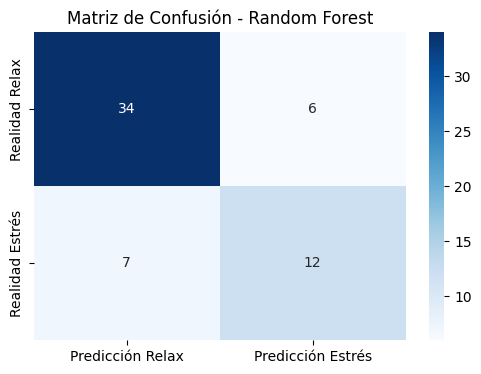

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Hacemos las predicciones sobre el conjunto de Test
y_pred = rf_model.predict(X_test)

# 1. Precisión general
print(f"Accuracy Global: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# 2. Reporte detallado (F1-Score, Precision, Recall)
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=['Relaxing (0)', 'Counting3 (1)']))

# 3. Matriz de Confusión Visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicción Relax', 'Predicción Estrés'],
            yticklabels=['Realidad Relax', 'Realidad Estrés'])
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# Sliding window approach (overlapped windows)

In [3]:
import os
import pandas as pd
import numpy as np

# Config
SAMPLING_RATE = 500
WINDOW_SIZE_SEC = 30
OVERLAP_SEC = 10  # Seconds of overlapping

SAMPLES_PER_WINDOW = SAMPLING_RATE * WINDOW_SIZE_SEC     # 15,000
OVERLAP_SAMPLES = SAMPLING_RATE * OVERLAP_SEC            # 7,500
STEP_SIZE = SAMPLES_PER_WINDOW - OVERLAP_SAMPLES         # 7,500 (How far we slide the window each time)

PATH = '../../StressIDDataset/StressID/StressID Dataset/Physiological'

# 1. Create an empty list to hold all our row dictionaries
all_session_rows = []

for subject in os.listdir(PATH):
    subject_path = os.path.join(PATH, subject)
    
    # skip any hidden files or non-directories
    if not os.path.isdir(subject_path):
        continue
        
    for file in os.listdir(subject_path):
        file_path = os.path.join(subject_path, file)
        
        # Load the data
        df_physio = pd.read_csv(file_path)
        
        # Extract activity from filename 
        activity = os.path.basename(file_path).split('.')[0].split('_')[1]

        # Extract the signals
        raw_signals = df_physio[['ECG', 'EDA', 'RR']].values
        total_samples = len(raw_signals)
        
        # If the file is shorter than one window, skip it to avoid errors
        if total_samples < SAMPLES_PER_WINDOW:
            continue

        # Calculate how many overlapping windows we can fit
        num_windows = (total_samples - SAMPLES_PER_WINDOW) // STEP_SIZE + 1

        # 2. Slide the window across the data
        for w in range(num_windows):
            start_idx = w * STEP_SIZE
            end_idx = start_idx + SAMPLES_PER_WINDOW
            
            # Slice the array instead of reshaping
            window_data = raw_signals[start_idx:end_idx]

            all_session_rows.append({
                'subject': subject,
                'activity': activity,
                'window_id': w,
                # window_data shape is (15000, 3). We grab all rows, specific column
                'ECG': window_data[:, 0].tolist(), 
                'EDA': window_data[:, 1].tolist(),
                'RR':  window_data[:, 2].tolist()
            })

# 3. Create the final DataFrame in one massive, lightning-fast operation
df_final_physio = pd.DataFrame(all_session_rows)

df_final_physio

,subject,activity,window_id,ECG,EDA,RR
0,9j3o,Math,0,"[33628, 33600, 33608, 33620, 33640, 33652, 336...","[34368, 34310, 34181, 34136, 34110, 34156, 342...","[36685, 36668, 36711, 36623, 36590, 36527, 365..."
1,9j3o,Math,1,"[31436, 31444, 31432, 31444, 31400, 31428, 314...","[32572, 32660, 32743, 32789, 32774, 32711, 326...","[31172, 31221, 31248, 31264, 31263, 31216, 311..."
2,9j3o,Baseline,0,"[32133, 32149, 32156, 32202, 32240, 32228, 322...","[26359, 26358, 26415, 26517, 26612, 26677, 266...","[24727, 24717, 24764, 24784, 24804, 24772, 248..."
3,9j3o,Baseline,1,"[32568, 32524, 32504, 32508, 32553, 32552, 325...","[28493, 28396, 28296, 28237, 28236, 28296, 284...","[25918, 25912, 25878, 25932, 25877, 25956, 259..."
4,9j3o,Reading,0,"[32392, 32448, 32457, 32456, 32464, 32500, 324...","[32127, 32112, 32140, 32226, 32312, 32393, 324...","[31288, 31308, 31333, 31384, 31359, 31416, 315..."
...,...,...,...,...,...,...
2819,b2l8,Reading,1,"[34020, 34028, 34132, 34240, 34337, 34392, 343...","[18270, 18277, 18260, 18256, 18156, 18137, 181...","[23793, 23577, 23719, 23587, 23583, 23495, 235..."
2820,b2l8,Speaking,0,"[32596, 32749, 32872, 33004, 33016, 32900, 327...","[17821, 17767, 17716, 17703, 17796, 17793, 178...","[31540, 31716, 31780, 31949, 32028, 32471, 325..."
2821,b2l8,Speaking,1,"[32144, 32248, 32428, 32688, 32904, 32998, 327...","[17821, 17827, 17781, 17730, 17748, 17677, 176...","[31172, 30945, 31100, 31063, 31132, 31105, 311..."
2822,b2l8,Math,0,"[32596, 32668, 32813, 33025, 33132, 33056, 329...","[17756, 17732, 17680, 17714, 17616, 17570, 176...","[22023, 22023, 21941, 21965, 21932, 21966, 219..."


In [4]:
len(set(df_final_physio['subject']))

65

In [10]:
df = feature_extraction_and_normalization(df_final_physio)
df

/home/ethe/miniconda3/envs/tfg/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/ethe/miniconda3/envs/tfg/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/ethe/miniconda3/envs/tfg/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the m

,subject,activity,window_id,ECG_Rate_Mean,EDA_Tonic_SD,HRV_AI,HRV_ApEn,HRV_C1a,HRV_C1d,HRV_C2a,...,RRV_SDSD,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
0,9j3o,Math,0,7.230782,-0.200472,2.626021,1.297867,3.266117,-3.266117,0.910928,...,35.704437,4.922665,10.920624,3.136717,19.311058,-23.092717,-0.994797,1.038667,-0.432085,2.121320
1,9j3o,Math,1,2.569132,-1.592276,-0.266386,0.644686,7.658185,-7.658185,2.986209,...,4.076382,0.776313,0.893115,0.128775,-31.850984,-0.905105,-19.243738,-5.227988,-2.059010,3.535534
2,9j3o,Baseline,0,-0.707107,0.707107,-0.707107,-0.707107,0.707106,-0.707106,0.707107,...,0.707107,-0.707107,0.707107,0.707107,0.707107,-0.707107,0.707106,0.707106,-0.707107,0.707107
3,9j3o,Baseline,1,0.707107,-0.707107,0.707107,0.707107,-0.707106,0.707106,-0.707107,...,-0.707107,0.707107,-0.707107,-0.707107,-0.707107,0.707107,-0.707106,-0.707106,0.707107,-0.707107
4,9j3o,Reading,0,-3.118748,-1.101327,2.336495,1.711228,-4.749398,4.749398,5.239599,...,12.062521,3.950770,-0.553923,-1.720262,-60.412814,-5.401327,-21.607831,-7.245699,-1.381320,0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1689,x1q3,Video2,0,-12.806512,-0.705866,0.550230,2.394079,-0.893612,0.893612,0.440288,...,-4.964288,-0.698321,18.072962,30.821009,2.351332,-2.573752,5.225513,22.487632,-0.370564,-0.068430
1690,x1q3,Video2,1,-16.403544,-0.772465,0.084810,-0.477294,0.213694,-0.213694,-0.920180,...,-5.367928,-5.797012,1.662126,40.541067,0.120614,3.900460,3.034593,48.154415,-0.853343,0.479008
1691,x1q3,Video2,2,-10.671684,-0.685385,-0.015813,-2.347429,0.075302,-0.075302,0.010291,...,-3.943688,-6.500280,-1.225935,41.452106,-0.169323,7.893521,1.917638,38.847859,-1.049385,1.710742
1692,x1q3,Counting1,0,-0.216386,-0.279288,-0.041567,0.503082,0.312459,-0.312459,-0.132894,...,10.001903,5.906254,4.911287,-4.665960,2.607817,-2.859587,4.390637,3.137584,0.116873,0.433388


In [11]:
len(set(df['subject']))

39

In [12]:
set(df_final_physio['subject']) - set(df['subject'])

{'45lx',
 '4woj',
 '6g6y',
 '6k5f',
 '8i4i',
 '9txq',
 'b2l8',
 'bfl5',
 'ctzy',
 'cxj0',
 'd4n6',
 'e5p4',
 'f6q3',
 'g9j5',
 'h8r2',
 'hh2e',
 'i9t9',
 'k2v7',
 'k67g',
 'ql3b',
 'r0a3',
 'r5s8',
 't6v9',
 'uymz',
 'wfsl',
 'y9z6'}

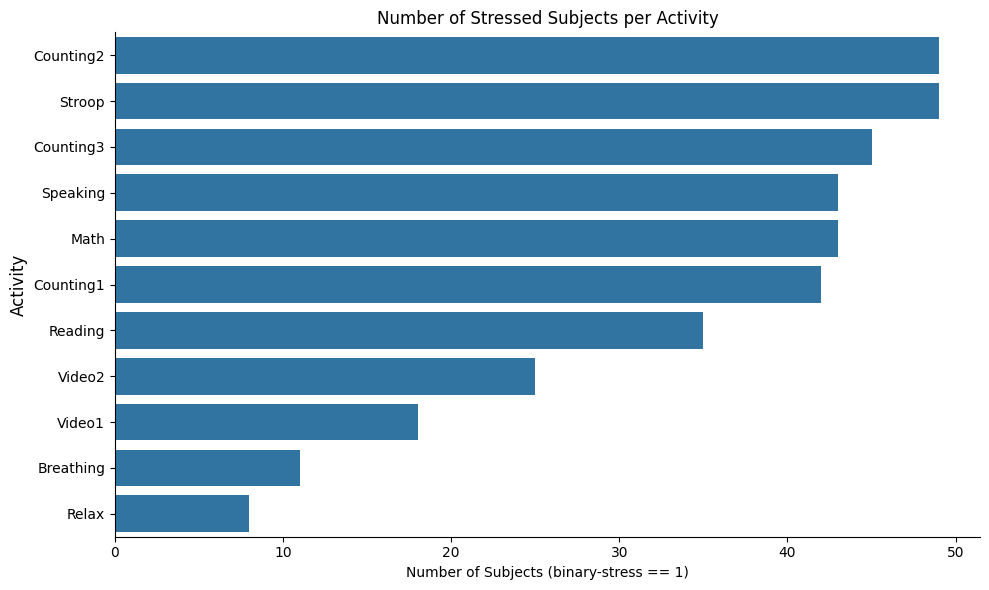

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data 
# Replace 'labels_file.csv' with the actual path to your label file
df_labels = pd.read_csv('../Dataset_StressID/StressIDDataset/labels_v2.csv', sep=';')

# 2. Split the 'subject/task' column into two separate columns
# n=1 ensures it only splits on the first underscore, just in case an activity name has an underscore
df_labels[['subject', 'activity']] = df_labels['subject/task'].str.split('_', n=1, expand=True)

# 3. Filter for only the stressed instances
# Assuming 'binary-stress' uses 1 for stressed and 0 for not stressed
df_stressed = df_labels[df_labels['binary-stress'] == 1]

# 4. Count the number of unique stressed subjects per activity
# We use .nunique() just in case a subject accidentally has multiple rows for the same task
stress_counts = df_stressed.groupby('activity')['subject'].nunique().sort_values(ascending=False)

# 5. Plot the results
plt.figure(figsize=(10, 6))
# A bar plot is perfect for comparing categorical counts
sns.barplot(x=stress_counts.values, y=stress_counts.index)

# Add formatting to make it look clean and academic
plt.title('Number of Stressed Subjects per Activity')
plt.xlabel('Number of Subjects (binary-stress == 1)')
plt.ylabel('Activity', fontsize=12)

# Despine to make the chart look cleaner
sns.despine()
plt.tight_layout()
plt.show()

Parece que Counting2 presenta el mayor número de casos estresantes, y Relax el que menos.

Sujetos en Train: 30
Sujetos en Test: 8
              precision    recall  f1-score   support

Breathing(0)       0.90      0.84      0.87        32
Counting2(1)       0.71      0.80      0.75        15

    accuracy                           0.83        47
   macro avg       0.80      0.82      0.81        47
weighted avg       0.84      0.83      0.83        47



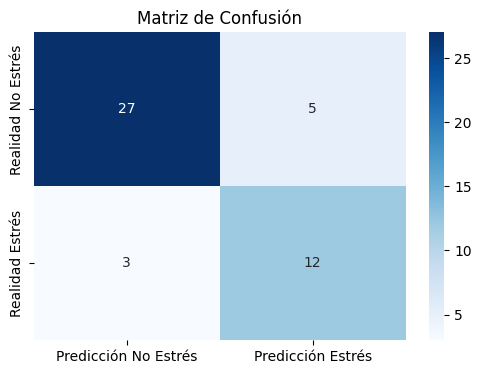

In [ ]:
from sklearn.ensemble import RandomForestClassifier

stress_act = 'Counting2'
non_stress_act = 'Relax'

X_train, X_test, y_train, y_test = train_test_split_per_subject(df, test_size=0.20, stress_act = stress_act, non_stress_act = non_stress_act)

# Inicializamos el Random Forest
rf = RandomForestClassifier(
    n_estimators=100,        # Número de árboles
    max_depth=10,            # Profundidad máxima (evita sobreajuste)
    class_weight='balanced', # Balancea clases si hay más ventanas de relax que de estrés
    random_state=123,
    n_jobs=-1                # Usa todos los núcleos de tu procesador
)

# Entrenamos el modelo con los datos de Train
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate_and_plot(y_pred=y_pred, y_test=y_test)

Es frustrante quedarte con solo 39 sujetos de los 65 simplemente porque se han quedado sin ventanas de Baseline para realizar la normalización... La idea ahora sería modificar la normalización e incluir otra actividad para complementar al baseline...

In [17]:
df = feature_extraction_and_normalization(df_final_physio)
df

/home/ethe/miniconda3/envs/tfg/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/ethe/miniconda3/envs/tfg/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/ethe/miniconda3/envs/tfg/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the m

,subject,activity,window_id,ECG_Rate_Mean,EDA_Tonic_SD,HRV_AI,HRV_ApEn,HRV_C1a,HRV_C1d,HRV_C2a,...,RRV_SDSD,RSP_Phase_Duration_Expiration,RSP_Phase_Duration_Inspiration,RSP_Phase_Duration_Ratio,RSP_RVT,RSP_Rate_Mean,RSP_Symmetry_PeakTrough,RSP_Symmetry_RiseDecay,SCR_Peaks_Amplitude_Mean,SCR_Peaks_N
0,9j3o,Math,0,2.395891,0.735464,1.799010,2.287730,-0.595359,0.595359,0.078493,...,3.123911,0.548505,-0.488811,-0.628630,1.883972,0.021313,-0.770848,-0.870449,0.715203,1.897367
1,9j3o,Math,1,1.419068,-0.664655,1.007485,1.293816,-0.039217,0.039217,0.562635,...,0.997112,-0.645932,-1.026021,-1.018532,-4.254114,1.050261,-3.724433,-1.930964,-0.252262,2.529822
2,9j3o,Baseline,0,0.732551,1.648464,0.886879,-0.763142,-0.919391,0.919391,0.030943,...,0.770548,-1.073259,-1.035986,-0.943566,-0.348008,1.059443,-0.495395,-0.926559,0.551659,1.264911
3,9j3o,Baseline,1,1.028891,0.225802,1.273887,1.388799,-1.098464,1.098464,-0.298979,...,0.675451,-0.665868,-1.111750,-1.126883,-0.517676,1.125027,-0.724285,-1.165888,1.392634,0.632456
4,9j3o,Reading,0,0.227205,-0.170774,1.719779,2.916722,-1.610315,1.610315,1.088329,...,1.534133,0.268531,-1.103544,-1.258212,-7.680775,0.841749,-4.107061,-2.272424,0.150732,1.264911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1855,b2l8,Counting1,1,0.453196,-0.362357,0.649159,2.013601,1.599863,-1.599863,-4.276475,...,14.428215,2.539814,-0.587983,-1.294393,-0.110661,-0.238124,8.001852,-2.149978,-0.555637,4.041452
1856,b2l8,Baseline,1,1.131097,0.292749,1.010770,0.935200,-1.116061,1.116061,-0.697484,...,0.982441,-1.154700,-1.154037,-1.153689,-1.111903,1.154610,0.489676,-1.152512,1.154699,-1.154701
1857,b2l8,Counting2,0,0.354544,17.947551,-0.178457,0.951572,0.420534,-0.420534,-1.635919,...,2.155677,-0.388333,-0.626722,-0.548304,-0.792561,0.621540,-0.579936,-0.277106,-0.371920,1.010363
1858,b2l8,Counting2,1,0.439268,2.599416,0.542590,3.387876,0.259930,-0.259930,-5.444422,...,10.013025,-0.319704,-0.019306,0.376729,-1.038459,-0.251491,-2.492379,0.848107,-0.465375,1.876388


In [18]:
set(df_final_physio['subject']) - set(df['subject'])

{'hh2e', 'k67g', 'wfsl'}

In [21]:
df.to_csv('./physiological_slidingwindow_features_normalized.csv', index=False)

In [19]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 123

def train_test_split_per_subject(df, test_size=0.20, stress_act = 'Counting2', non_stress_act = 'Breathing'):
    df_model = df[df['activity'].isin([stress_act, non_stress_act])].copy()

    # Creamos la etiqueta: 0 No estrés, 1 Estrés
    df_model['target'] = (df_model['activity'] == stress_act).astype(int)

    # Separamos las características (X) de las etiquetas (y) y los grupos (Sujetos)
    feature_cols = [col for col in df_model.columns if col not in ['subject', 'activity', 'window_id', 'target']]

    X = df_model[feature_cols]
    y = df_model['target']
    subjects = df_model['subject']


    # Configuramos la división: 80% sujetos para Train, 20% sujetos para Test
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)

    # Obtenemos los índices de las filas para cada conjunto
    train_idx, test_idx = next(gss.split(X, y, groups=subjects))

    # Creamos los DataFrames finales de entrenamiento y prueba
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    print(f"Sujetos en Train: {df_model.iloc[train_idx]['subject'].nunique()}")
    print(f"Sujetos en Test: {df_model.iloc[test_idx]['subject'].nunique()}")

    return X_train, X_test, y_train, y_test

def evaluate_and_plot(y_test, y_pred, stress_act = 'Counting2', non_stress_act = 'Breathing'):

    print(classification_report(y_test, y_pred, target_names=[f'{non_stress_act}(0)', f'{stress_act}(1)']))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicción No Estrés', 'Predicción Estrés'],
                yticklabels=['Realidad No Estrés', 'Realidad Estrés'])
    plt.title('Matriz de Confusión')
    plt.show()


Sujetos en Train: 47
Sujetos en Test: 12
              precision    recall  f1-score   support

Breathing(0)       0.78      0.88      0.83        43
Counting2(1)       0.67      0.48      0.56        21

    accuracy                           0.75        64
   macro avg       0.72      0.68      0.69        64
weighted avg       0.74      0.75      0.74        64



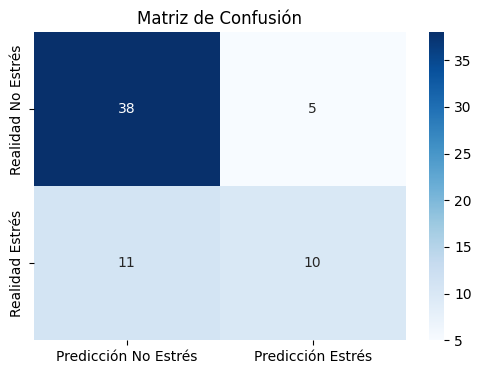

In [20]:
X_train, X_test, y_train, y_test = train_test_split_per_subject(df, test_size=0.20, stress_act = 'Counting2', non_stress_act = 'Breathing')

rf = RandomForestClassifier(
    n_estimators=100,        # Número de árboles
    max_depth=10,            # Profundidad máxima (evita sobreajuste)
    class_weight='balanced', # Balancea clases si hay más ventanas de relax que de estrés
    random_state=123,
    n_jobs=-1                # Usa todos los núcleos de tu procesador
)

# Entrenamos el modelo con los datos de Train
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate_and_plot(y_pred=y_pred, y_test=y_test)

## GRID SEARCH > WIP!!!

In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Hyperparameter Grid
# We keep this relatively contained so it doesn't take hours to run.
param_grid = {
    'n_estimators': np.arange(10, 300, 10),       # Number of trees in the forest
    'max_depth': [None, 10, 20],           # Maximum depth of the tree (limits overfitting)
    'min_samples_split': [2, 5, 10],       # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],         # Minimum samples required to be at a leaf node
    'max_features': ['sqrt', 'log2']       # Number of features to consider at every split
}

# 2. Set up the Grouped Cross-Validation for the Grid Search
# n_splits=5 means it will divide your training subjects into 5 groups
gkf = GroupKFold(n_splits=5)

# 3. Initialize the Base Model
# Notice we keep class_weight='balanced' to handle the imbalanced Relax vs Counting windows!
rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)

# 4. Initialize the Grid Search
# scoring='f1_macro' is best here since you care equally about both classes despite the imbalance
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=gkf,
    scoring='f1_macro', 
    n_jobs=-1, # Uses all available CPU cores to speed up the process
    verbose=2  # Prints progress updates to the console
)

# 5. We need to isolate the subject groups for the training data specifically
# (Assuming you already ran your GroupShuffleSplit from earlier)
grupos_train = grupos_sujetos.iloc[train_idx]

# 6. Fit the Grid Search
print("Starting Grid Search... This might take a few minutes!")
grid_search.fit(X_train, y_train, groups=grupos_train)

# 7. Extract and print the best results
print("\n--- Grid Search Results ---")
print(f"Best Macro F1-Score: {grid_search.best_score_:.4f}")
print("Best Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

# 8. Save the best model for your final test set
best_rf_model = grid_search.best_estimator_